In [ ]:
%matplotlib inline
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from scipy import stats
import pyshtools as pysh

# ─────────────────────────────────────────────────────────
# 全局样式
# ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Times New Roman"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "xtick.direction": "out",
    "ytick.direction": "out",

    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

PROJ = ccrs.PlateCarree()

# Apollo 15 参考信息（Kim et al., 2025）
A15_LON   = 3.634
A15_LAT   = 26.132
A15_THICK = 29.4e3   # m

A12_LON   = -23.421
A12_LAT   = -3.012
A12_THICK = 34.4e3   # m

A16_LON   = 15.498
A16_LAT   = -8.973
A16_THICK = 30.0e3   # m

# ─────────────────────────────────────────────────────────
# 读取 pkl
# ─────────────────────────────────────────────────────────
print("读取 pkl 文件…")
with open("final_result.pkl", "rb") as fh:
    fin = pickle.load(fh)
with open("crosstest_result.pkl", "rb") as fh:
    crs = pickle.load(fh)

# ── final_result 字段
LON_full       = fin["LON"]                      # (nlat, nlon)
LAT_full       = fin["LAT"]
topo_full      = fin["topo"]                     # m
input_g_full   = fin["input_g"]                  # 校正后布格重力 mGal
crust_dens_full = fin["crust_density"]           # 有效月壳密度 kg/m³
ct_raw         = fin["crust_thickness"].copy()   # km（含负值）
da_full        = fin["density_anomaly"]          # 横向密度异常 kg/m³
g_rho_full     = fin["g_rho"]                    # 密度横向重力校正 mGal
resid_full     = fin["residuals"]                # obs − pred mGal
rms_hist       = np.asarray(fin["rms"])          # 收敛历史
best_por       = fin["porosity"]
best_rho_m     = fin["mantle_rho"]
best_ct_m      = fin["best_ct_m"]
best_mu        = fin["best_mu"]
a15_inv        = fin["apollo15_thick_inv"]       # m

# ── crosstest_result 字段
mu_vals_arr   = np.asarray(crs["mu_vals"])
mu_rms_dict   = crs["mu_rms"]
por_vals      = np.asarray(crs["porosity_vals"])
rho_m_vals    = np.asarray(crs["mantle_rho_vals"])
ct_scan_vals  = np.asarray(crs["crust_thick_vals"])
results_dict  = crs["results_dict"]
best_por_cv   = crs["best_por"]
best_rho_m_cv = crs["best_rho_m"]
best_ct_m_cv  = crs["best_ct_m"]

# NaN 填充负月壳厚度
ct_full = ct_raw.copy()
ct_full[ct_full < 0] = np.nan

# ── 1° 边缘裁剪
lon_arr  = LON_full[0, :]
lat_arr  = LAT_full[:, 0]
lon_mask = (lon_arr >= lon_arr[0] + 1.0) & (lon_arr <= lon_arr[-1] - 1.0)
lat_mask = (lat_arr >= lat_arr[0] + 1.0) & (lat_arr <= lat_arr[-1] - 1.0)
ii_lat   = np.where(lat_mask)[0]
ii_lon   = np.where(lon_mask)[0]

def _crop(a):
    return a[np.ix_(ii_lat, ii_lon)]

LON_p  = _crop(LON_full)
LAT_p  = _crop(LAT_full)
topo_p = _crop(topo_full)
ct_p   = _crop(ct_full)
ig_p   = _crop(input_g_full)
cd_p   = _crop(crust_dens_full)
da_p   = _crop(da_full)
gr_p   = _crop(g_rho_full)
rs_p   = _crop(resid_full)

EXTENT = [float(LON_p.min()), float(LON_p.max()),
          float(LAT_p.min()), float(LAT_p.max())]

# topography data
LDEM=pysh.datasets.Moon.LDEM_shape_pa()
topo_grid=LDEM.expand(grid='DH',lmax=1200,extend=False)
topo=topo_grid.to_xarray()


# ─────────────────────────────────────────────────────────
# 工具函数
# ─────────────────────────────────────────────────────────

def _sym_lim(data, plo=1, phi=99):
    cen  = float(np.nanmean(data))
    half = max(abs(np.nanpercentile(data, plo) - cen),
               abs(np.nanpercentile(data, phi) - cen))
    return cen - half, cen + half


def _gridlines(ax, extent, dlon=5, dlat=5, left=True, bottom=True):
    gl = ax.gridlines(
        crs=PROJ, draw_labels=True,
        linewidth=0.35, color="#666666", alpha=0.55,
        linestyle="--", x_inline=False, y_inline=False,
    )
    gl.top_labels    = False
    gl.right_labels  = False
    gl.left_labels   = left
    gl.bottom_labels = bottom
    gl.xlocator = mticker.FixedLocator(
        np.arange(np.ceil(extent[0] / dlon) * dlon, extent[1] + dlon, dlon))
    gl.ylocator = mticker.FixedLocator(
        np.arange(np.ceil(extent[2] / dlat) * dlat, extent[3] + dlat, dlat))
    gl.xlabel_style = {"size": 7.5, "color": "#222222"}
    gl.ylabel_style = {"size": 7.5, "color": "#222222"}


def _topo_cont(ax, step=1000):
    vmin = np.floor(np.nanmin(topo_p) / step) * step
    vmax = np.ceil(np.nanmax(topo_p) / step) * step
    levels = np.arange(vmin, vmax + step, step)
    ax.contour(LON_p, LAT_p, topo_p,
               levels=levels,
               colors="black", linewidths=0.28, alpha=0.80,
               transform=PROJ)


def _mark_a15(ax):
    ax.plot(A15_LON, A15_LAT,
            marker="^", color="#EE2222", markersize=7,
            markeredgewidth=0.6, markeredgecolor="white",
            transform=PROJ, zorder=10,
            label=(f"Apollo 15\n"
                   f"Inv: {a15_inv/1e3:.1f} km\n"
                   f"Seis: {A15_THICK/1e3:.1f} km"))
    ax.plot(A12_LON, A12_LAT,
            marker="^", color="#EE8822", markersize=7,
            markeredgewidth=0.6, markeredgecolor="white",
            transform=PROJ, zorder=10,
            label=(f"Apollo 12\n"
                   f"Inv: {A12_THICK/1e3:.1f} km\n"
                   f"Seis: {A12_THICK/1e3:.1f} km"))
    ax.plot(A16_LON, A16_LAT,
            marker="^", color="#EE88EE", markersize=7,
            markeredgewidth=0.6, markeredgecolor="white",
            transform=PROJ, zorder=10,
            label=(f"Apollo 16\n"
                   f"Inv: {A16_THICK/1e3:.1f} km\n"
                   f"Seis: {A16_THICK/1e3:.1f} km"))
    ax.text(A15_LON, A15_LAT - 1.2, "A15", transform=PROJ,
            fontsize=7.5, fontweight="bold", color="#000000",
            ha="center", va="top", zorder=11)
    ax.text(A12_LON, A12_LAT - 1.2, "A12", transform=PROJ,
            fontsize=7.5, fontweight="bold", color="#000000",
            ha="center", va="top", zorder=11)
    ax.text(A16_LON, A16_LAT - 1.2, "A16", transform=PROJ,
            fontsize=7.5, fontweight="bold", color  ="#000000",
            ha="center", va="top", zorder=11)
#    ax.legend(loc="upper right", fontsize=7.5,
#              handlelength=0.7, handletextpad=0.35,
#              borderpad=0.4, framealpha=0.88)


def _cbar(fig, ax, im, label, shrink=0.82, aspect=24):
    cb = fig.colorbar(im, ax=ax, shrink=shrink, aspect=aspect,
                      pad=0.03, orientation="vertical")
    cb.set_label(label, fontsize=8.5)
    cb.ax.tick_params(labelsize=7.5, width=0.5, length=2)
    cb.outline.set_linewidth(0.5)
    return cb


def _tag(ax, label, geo=True, x=0.020, y=0.968):
    kw = {"transform": ax.transAxes} if geo else {}
    ax.text(x, y, f"({label})", **kw,
            fontsize=10, fontweight="bold",
            va="top", ha="left", color="white",
            bbox=dict(boxstyle="round,pad=0.18",
                      facecolor="#1a1a1a", edgecolor="none", alpha=0.72))


def _despine(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_linewidth(0.7)

读取 pkl 文件…


In [2]:
# # ═══════════════════════════════════════════════════════════
# # 图 1+2：μ 评分曲线（上）+ 三参数扫描热图（下）
# # ═══════════════════════════════════════════════════════════
# print("图1+2：μ 优化 + 参数扫描…")

# import matplotlib.gridspec as gridspec

# mu_rms_arr = np.array([mu_rms_dict[v] for v in mu_vals_arr])
# best_idx   = int(np.argmin(mu_rms_arr))

# n_por = len(por_vals)
# ct_km = ct_scan_vals / 1e3

# # 先把所有 MAE 矩阵算出来，定 vmin/vmax
# all_mae = []
# for por in por_vals:
#     mae_mat = np.array([
#         [results_dict[(por, rm, round(ct, 1))] / 1e3
#          for ct in ct_scan_vals]
#         for rm in rho_m_vals
#     ])
#     all_mae.append(mae_mat)
# vmin = np.min(all_mae)
# vmax = np.max(all_mae)

# # ── Figure + GridSpec ────────────────────────────────────
# fig = plt.figure(figsize=(8.5, 7.2))
# gs  = gridspec.GridSpec(
#     2, n_por,
#     height_ratios=[1.0, 1.0],
#     hspace=0.38, wspace=0.18,
#     figure=fig,
# )

# # ========= (a) μ 评分曲线：顶部整行 =========
# ax1 = fig.add_subplot(gs[0, :])
# _despine(ax1)

# ax1.semilogx(mu_vals_arr, mu_rms_arr,
#              color="steelblue", linewidth=1.5, zorder=3,
#              marker="o", markersize=7,
#              markerfacecolor="white", markeredgewidth=1.5,
#              markeredgecolor="steelblue", label="Test-set RMS")
# ax1.fill_between(mu_vals_arr, mu_rms_arr, alpha=0.10, color="steelblue")
# ax1.plot(mu_vals_arr[best_idx], mu_rms_arr[best_idx],
#          marker="*", markersize=15, color="#CC1111", zorder=5,
#          markeredgecolor="white", markeredgewidth=0.5,
#          label=(f"Optimal  $\\mu$ = {best_mu:.2e}\n"
#                 f"RMS = {mu_rms_arr[best_idx]:.4f} mGal"))
# ax1.axvline(best_mu, color="#CC1111", linestyle="--",
#             linewidth=1.0, alpha=0.60)

# for mv, rv in zip(mu_vals_arr, mu_rms_arr):
#     ax1.annotate(f"{rv:.3f}", xy=(mv, rv),
#                  xytext=(0, 10), textcoords="offset points",
#                  ha="center", fontsize=6.5, color="#444444",
#                  rotation=55)

# ax1.set_xlabel("Regularization parameter  $\\mu$", labelpad=6)
# ax1.set_ylabel("Test-set RMS  (mGal)", labelpad=6)
# # ax1.set_title("Regularization parameter optimization\n"
# #               "(train / test cross-validation,  10 log-spaced values)", pad=8)
# ax1.legend(loc="upper left", framealpha=0.88)
# ax1.grid(True, which="both", alpha=0.28, linewidth=0.4, zorder=0)
# ax1.yaxis.set_minor_locator(mticker.AutoMinorLocator())
# ax1.set_ylim(20, 35)
# ax1.set_xlim(1e-10, 1e-2)
# for spine in ax1.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(0.8)

# ax1.text(-0.045, 1, "(a)", transform=ax1.transAxes,
#          fontsize=12, fontweight="bold", va="bottom", ha="left")

# # ========= (b) 三参数扫描热图：下一行 =========
# axes2 = [fig.add_subplot(gs[1, i]) for i in range(n_por)]
# im2 = None

# for col, por in enumerate(por_vals):
#     mae_mat = all_mae[col]
#     ax = axes2[col]
#     _despine(ax)

#     im2 = ax.pcolormesh(
#         ct_km, rho_m_vals, mae_mat,
#         cmap="viridis_r", shading="auto",
#         vmin=vmin, vmax=vmax,
#     )

#     cs2 = ax.contour(
#         ct_km, rho_m_vals, mae_mat,
#         levels=6, colors="white",
#         linewidths=0.55, alpha=0.55,
#     )
#     ax.clabel(cs2, fmt="%.2f", fontsize=6.5, inline=True, inline_spacing=3)

#     if np.isclose(por, best_por_cv):
#         mae_best = results_dict[
#             (best_por_cv, best_rho_m_cv, round(best_ct_m_cv, 1))
#         ] / 1e3
#         ax.plot(
#             best_ct_m_cv / 1e3, best_rho_m_cv,
#             marker="*", color="#FF3333", markersize=15, zorder=7,
#             markeredgecolor="white", markeredgewidth=0.6,
#             label=(f"Optimal\n"
#                    f"$H_0$ = {best_ct_m_cv/1e3:.0f} km\n"
#                    f"$\\rho_m$ = {best_rho_m_cv:.0f} kg m$^{{-3}}$\n"
#                    f"MAE = {mae_best:.3f} km"),
#         )
#         ax.legend(fontsize=7, loc="upper right",
#                   framealpha=0.88, handlelength=1.3)

#     ax.set_xlabel("$H_0$  (km)", labelpad=5)
#     if col == 0:
#         ax.set_ylabel("Mantle density  $\\rho_m$  (kg m$^{-3}$)", labelpad=5)
#     else:
#         ax.set_ylabel("")
#         ax.tick_params(labelleft=False)

#     ax.set_title(f"Porosity  $\\phi$ = {por:.2f}",
#                  pad=7, fontweight="semibold")
#     ax.set_yticks(rho_m_vals)
#     ax.tick_params(width=0.7, length=3, direction="out")

#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_linewidth(0.8)

# axes2[0].text(-0.1, 1, "(b)", transform=axes2[0].transAxes,
#               fontsize=12, fontweight="bold", va="bottom", ha="left")

# axes2[1].text(-0.1, 1, "(c)", transform=axes2[1].transAxes,
#               fontsize=12, fontweight="bold", va="bottom", ha="left")


# # 共享 colorbar（只贴在热图这一行右侧）
# cb2 = fig.colorbar(
#     im2, ax=axes2, location="right",
#     fraction=0.035, pad=0.04,
# )
# cb2.set_label("Apollo 15  MAE  (km)", fontsize=8.5)
# cb2.ax.tick_params(labelsize=7.5, width=0.5, length=2)
# cb2.outline.set_linewidth(0.5)

# fig.savefig("figure/mu_and_param_scan.png",
#             bbox_inches="tight", facecolor="white")
# plt.show()
# print("  → mu_and_param_scan.png")

图1+2：μ 优化 + 参数扫描 (φ=0.07) …


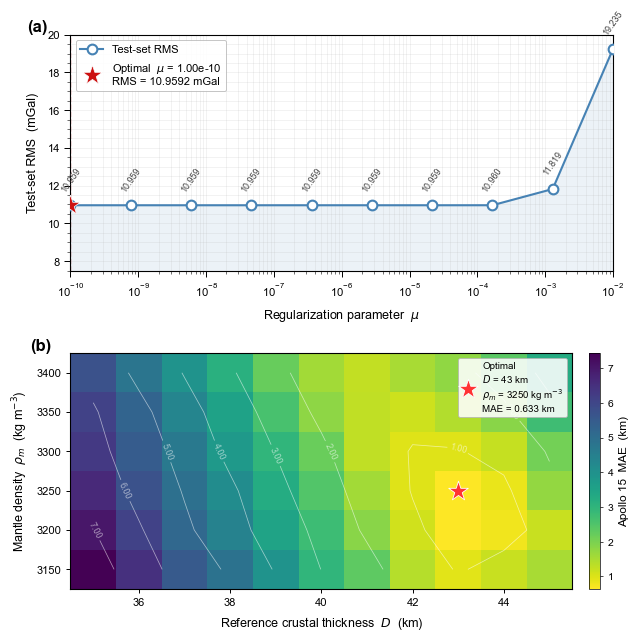

  → mu_and_param_scan.png


In [3]:
# ═══════════════════════════════════════════════════════════
# 图 1+2：μ 评分曲线（上）+ 参数扫描热图（下，仅 φ=0.07）
# ═══════════════════════════════════════════════════════════
print("图1+2：μ 优化 + 参数扫描 (φ=0.07) …")

import matplotlib.gridspec as gridspec

mu_rms_arr = np.array([mu_rms_dict[v] for v in mu_vals_arr])
best_idx   = int(np.argmin(mu_rms_arr))

ct_km = ct_scan_vals / 1e3

# 只保留 φ=0.07 那张热图
TARGET_POR = 0.07
por_sel = por_vals[np.argmin(np.abs(por_vals - TARGET_POR))]

mae_mat = np.array([
    [results_dict[(por_sel, rm, round(ct, 1))] / 1e3
     for ct in ct_scan_vals]
    for rm in rho_m_vals
])
vmin = float(np.min(mae_mat))
vmax = float(np.max(mae_mat))

# ── Figure + GridSpec ────────────────────────────────────
fig = plt.figure(figsize=(7.0, 7.2))
gs  = gridspec.GridSpec(
    2, 1,
    height_ratios=[1.0, 1.0],
    hspace=0.35,
    figure=fig,
)

# ========= (a) μ 评分曲线 =========
ax1 = fig.add_subplot(gs[0, 0])
_despine(ax1)

ax1.semilogx(mu_vals_arr, mu_rms_arr,
             color="steelblue", linewidth=1.5, zorder=3,
             marker="o", markersize=7,
             markerfacecolor="white", markeredgewidth=1.5,
             markeredgecolor="steelblue", label="Test-set RMS")
ax1.fill_between(mu_vals_arr, mu_rms_arr, alpha=0.10, color="steelblue")
ax1.scatter(
    mu_vals_arr[best_idx], mu_rms_arr[best_idx],
    marker="*", s=220, color="#CC1111", zorder=5,
    edgecolors="white", linewidths=0.5,
    label=(f"Optimal  $\\mu$ = {best_mu:.2e}\n"
           f"RMS = {mu_rms_arr[best_idx]:.4f} mGal"),
)
ax1.axvline(best_mu, color="#CC1111", linestyle="--",
            linewidth=1.0, alpha=0.60)

for mv, rv in zip(mu_vals_arr, mu_rms_arr):
    ax1.annotate(f"{rv:.3f}", xy=(mv, rv),
                 xytext=(0, 10), textcoords="offset points",
                 ha="center", fontsize=6.5, color="#444444",
                 rotation=55)

ax1.set_xlabel("Regularization parameter  $\\mu$", labelpad=6)
ax1.set_ylabel("Test-set RMS  (mGal)", labelpad=6)
ax1.legend(loc="upper left", framealpha=0.88)
ax1.grid(True, which="both", alpha=0.28, linewidth=0.4, zorder=0)
ax1.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.set_ylim(7.5, 20)
ax1.set_xlim(1e-10, 1e-2)
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

ax1.text(-0.08, 1.0, "(a)", transform=ax1.transAxes,
         fontsize=12, fontweight="bold", va="bottom", ha="left")

# ========= (b) 参数扫描热图 (φ = 0.07) =========
ax2 = fig.add_subplot(gs[1, 0])
_despine(ax2)

im2 = ax2.pcolormesh(
    ct_km, rho_m_vals, mae_mat,
    cmap="viridis_r", shading="auto",
    vmin=vmin, vmax=vmax,
)

cs2 = ax2.contour(
    ct_km, rho_m_vals, mae_mat,
    levels=6, colors="white",
    linewidths=0.55, alpha=0.55,
)
ax2.clabel(cs2, fmt="%.2f", fontsize=6.5, inline=True, inline_spacing=3)

# 标记最优点（如果当前最优 porosity 正好是 0.07）
if np.isclose(por_sel, best_por_cv):
    mae_best = results_dict[
        (best_por_cv, best_rho_m_cv, round(best_ct_m_cv, 1))
    ] / 1e3
    ax2.scatter(
        best_ct_m_cv / 1e3, best_rho_m_cv,
        marker="*", color="#FF3333", s=220, zorder=7,
        edgecolors="white", linewidths=0.6,
        label=(f"Optimal\n"
            f"$D$ = {best_ct_m_cv/1e3:.0f} km\n"
            f"$\\rho_m$ = {best_rho_m_cv:.0f} kg m$^{{-3}}$\n"
            f"MAE = {mae_best:.3f} km"),
    )
    ax2.legend(fontsize=7, loc="upper right",
               framealpha=0.88, handlelength=1.3)

ax2.set_xlabel("Reference crustal thickness  $D$  (km)", labelpad=5)
ax2.set_ylabel("Mantle density  $\\rho_m$  (kg m$^{-3}$)", labelpad=5)
# ax2.set_title(f"Porosity  $\\phi$ = {por_sel:.2f}",
#               pad=7, fontweight="semibold")
ax2.set_yticks(rho_m_vals)
ax2.tick_params(width=0.7, length=3, direction="out")

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

ax2.text(-0.08, 1.0, "(b)", transform=ax2.transAxes,
         fontsize=12, fontweight="bold", va="bottom", ha="left")

# colorbar 贴在热图右侧
cb2 = fig.colorbar(
    im2, ax=ax2, location="right",
    fraction=0.045, pad=0.03,
)
cb2.set_label("Apollo 15  MAE  (km)", fontsize=8.5)
cb2.ax.tick_params(labelsize=7.5, width=0.5, length=2)
cb2.outline.set_linewidth(0.5)

fig.savefig("figure/figure9_mu_and_param_scan.png",
            bbox_inches="tight", facecolor="white")
plt.show()
print("  → mu_and_param_scan.png")

图3：月壳厚度…


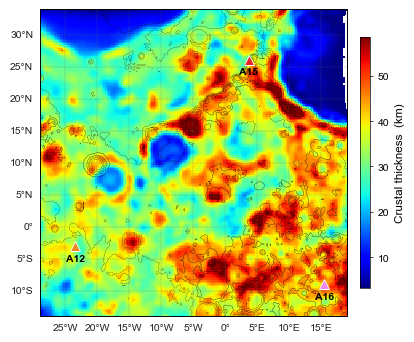

  → crustal_thick.png


In [4]:
# ═══════════════════════════════════════════════════════════
# 图 3：月壳厚度（负值 → NaN）
# ═══════════════════════════════════════════════════════════
print("图3：月壳厚度…")

nan_frac = float(np.isnan(ct_p).sum()) / ct_p.size * 100

fig3 = plt.figure(figsize=(4.5, 3.5))
ax3  = fig3.add_subplot(1, 1, 1, projection=PROJ)
ax3.set_extent(EXTENT, crs=PROJ)

im3 = ax3.pcolormesh(LON_p, LAT_p, ct_p,
                     cmap="jet",
                     vmin=np.nanpercentile(ct_p, 1),
                     vmax=np.nanpercentile(ct_p, 99),
                     shading="auto", transform=PROJ, rasterized=True)
_topo_cont(ax3)
_gridlines(ax3, EXTENT)
_mark_a15(ax3)
_cbar(fig3, ax3, im3, "Crustal thickness  (km)")
#_tag(ax3, "a")
#ax3.set_title(
#    f"Lunar crustal thickness\n"
#    f"$\\rho_m$ = {best_rho_m:.0f} kg m$^{{-3}}$,  "
#    f"$H_0$ = {best_ct_m/1e3:.0f} km,  $\\phi$ = {best_por:.2f}\n"
#    f"Negative values replaced by NaN  ({nan_frac:.1f}% of domain)",
#    pad=7, fontsize=9,
#)
ax3.set_aspect('equal')
fig3.tight_layout()
fig3.savefig(r"figure/figure11_crustal_thick.png", bbox_inches="tight", facecolor="white")
plt.show()
print("  → crustal_thick.png")


图4：2×2 综合图…


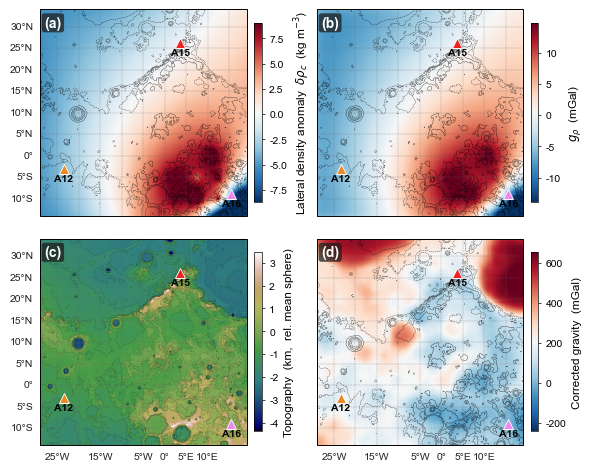

  → topography.png


In [5]:
# ═══════════════════════════════════════════════════════════
# 图 4：2×2  密度异常 / g_rho  ——  地形 / 输入重力
# ═══════════════════════════════════════════════════════════
print("图4：2×2 综合图…")

fig4 = plt.figure(figsize=(7.0, 7.0))
ax_a = fig4.add_subplot(2, 2, 1, projection=PROJ)  # 密度异常
ax_b = fig4.add_subplot(2, 2, 2, projection=PROJ)  # g_rho
ax_c = fig4.add_subplot(2, 2, 3, projection=PROJ)  # 地形
ax_d = fig4.add_subplot(2, 2, 4, projection=PROJ)  # 输入重力

# ── (a) 横向密度异常 ─────────────────────────────────────
ax_a.set_extent(EXTENT, crs=PROJ)
vmin_da, vmax_da = _sym_lim(da_p, plo=2, phi=98)
im_a = ax_a.pcolormesh(LON_p, LAT_p, da_p,
                       cmap="RdBu_r", vmin=vmin_da, vmax=vmax_da,
                       shading="auto", transform=PROJ, rasterized=True)
_topo_cont(ax_a, step=1000)
_gridlines(ax_a, EXTENT, left=True,  bottom=False)
_mark_a15(ax_a)
_cbar(fig4, ax_a, im_a,
      "Lateral density anomaly  $\\delta\\rho_c$  (kg m$^{-3}$)")
_tag(ax_a, "a")

# ── (b) 密度重力校正量 g_rho ─────────────────────────────
ax_b.set_extent(EXTENT, crs=PROJ)
vmin_gr, vmax_gr = _sym_lim(gr_p, plo=1, phi=99)
im_b = ax_b.pcolormesh(LON_p, LAT_p, gr_p,
                       cmap="RdBu_r", vmin=vmin_gr, vmax=vmax_gr,
                       shading="auto", transform=PROJ, rasterized=True)
_topo_cont(ax_b, step=1000)
_gridlines(ax_b, EXTENT, left=False, bottom=False)
_mark_a15(ax_b)
_cbar(fig4, ax_b, im_b, "$g_\\rho$  (mGal)")
_tag(ax_b, "b")

# ── (c) 地形 ─────────────────────────────────────────────
ax_c.set_extent(EXTENT, crs=PROJ)
im_c = ax_c.pcolormesh(LON_p, LAT_p, topo_p / 1e3,
                       cmap="gist_earth",
                       shading="auto", transform=PROJ, rasterized=True)
vlo4 = np.nanpercentile(topo_p / 1e3, 5)
vhi4 = np.nanpercentile(topo_p / 1e3, 95)
ax_c.contour(LON_p, LAT_p, topo_p / 1e3,
             levels=np.linspace(vlo4, vhi4, 10),
             colors="#111111", linewidths=0.28, alpha=0.38,
             transform=PROJ)
_gridlines(ax_c, EXTENT, left=True, bottom=True)
_mark_a15(ax_c)
_cbar(fig4, ax_c, im_c, "Topography  (km,  rel. mean sphere)")
_tag(ax_c, "c")

# ── (d) 密度校正后的布格重力（反演输入） ────────────────
ax_d.set_extent(EXTENT, crs=PROJ)
vmin_ig, vmax_ig = _sym_lim(ig_p, plo=1, phi=99)
im_d = ax_d.pcolormesh(LON_p, LAT_p, ig_p,
                       cmap="RdBu_r", vmin=vmin_ig, vmax=vmax_ig,
                       shading="auto", transform=PROJ, rasterized=True)
_topo_cont(ax_d, step=1000)
_gridlines(ax_d, EXTENT, left=False, bottom=True)
_mark_a15(ax_d)
_cbar(fig4, ax_d, im_d, "Corrected gravity  (mGal)")
_tag(ax_d, "d")

fig4.subplots_adjust(wspace=0.1, hspace=0.05,
                     left=0.045, right=0.8,
                     top=0.7, bottom=0.06)
fig4.savefig("figure/figure8_topography.png", bbox_inches="tight", facecolor="white")
plt.show()
print("  → topography.png")

图7：收敛曲线 + 残差直方图…


/var/folders/xb/p9yw1hp93wxfx_mg6rcxlhmr0000gn/T/ipykernel_26254/3262538769.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig7.tight_layout()


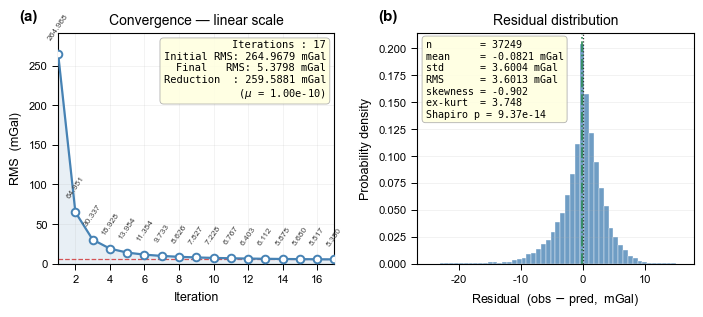

  → rms_and_residual.png


In [8]:
# ═══════════════════════════════════════════════════════════
# 图 7：收敛曲线 + 残差直方图
# ═══════════════════════════════════════════════════════════
print("图7：收敛曲线 + 残差直方图…")

iters     = np.arange(1, len(rms_hist) + 1)
delta_rms = rms_hist[0] - rms_hist[-1]

rs_flat   = rs_p[np.isfinite(rs_p)].ravel()
rms_final = float(np.sqrt(np.nanmean(rs_p ** 2)))

fig7, (ax7a, ax8a) = plt.subplots(1, 2, figsize=(8.2, 3.0),
                                  gridspec_kw={"wspace": 0.30})

# ── (a) 收敛曲线 ─────────────────────────────────────────
_despine(ax7a)
ax7a.plot(iters, rms_hist,
          color="steelblue", linewidth=1.6, zorder=3,
          marker="o", markersize=5.5,
          markerfacecolor="white", markeredgewidth=1.4,
          markeredgecolor="steelblue")
ax7a.fill_between(iters, rms_hist, alpha=0.12, color="steelblue")
ax7a.axhline(rms_hist[-1], color="#CC1111", linestyle="--",
             linewidth=0.9, alpha=0.70,
             label=f"Final RMS = {rms_hist[-1]:.4f} mGal")
ax7a.set_xlabel("Iteration", labelpad=5)
ax7a.set_ylabel("RMS  (mGal)", labelpad=5)
ax7a.set_title("Convergence — linear scale", pad=6)
ax7a.grid(True, which="both", alpha=0.27, linewidth=0.38)
ax7a.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

if len(iters) <= 25:
    for it, rv in zip(iters, rms_hist):
        ax7a.annotate(f"{rv:.3f}", xy=(it, rv),
                      xytext=(0, 10), textcoords="offset points",
                      ha="center", fontsize=6.0, color="#444444",
                      rotation=55)

ax7a.text(0.97, 0.97,
          f"Iterations : {len(rms_hist)}\n"
          f"Initial RMS: {rms_hist[0]:.4f} mGal\n"
          f"Final   RMS: {rms_hist[-1]:.4f} mGal\n"
          f"Reduction  : {delta_rms:.4f} mGal\n"
          f"($\\mu$ = {best_mu:.2e})",
          transform=ax7a.transAxes, fontsize=7.5,
          va="top", ha="right", family="monospace",
          bbox=dict(boxstyle="round,pad=0.35", facecolor="lightyellow",
                    edgecolor="0.65", alpha=0.88))

ax7a.set_xlim(1, len(rms_hist))
ax7a.set_ylim(0, rms_hist[0] * 1.10)
for spine in ax7a.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
# _tag(ax7a, "a", geo=False)

# ── (b) 残差直方图 ───────────────────────────────────────
_despine(ax8a)
ax8a.hist(rs_flat, bins=52,
          color="steelblue", alpha=0.78,
          edgecolor="white", linewidth=0.35,
          density=True, label="Residual distribution")

mu_fit, sig_fit = stats.norm.fit(rs_flat)

ax8a.axvline(0, color="#333333", linewidth=0.9, linestyle=":")
ax8a.axvline(float(np.mean(rs_flat)), color="seagreen",
             linewidth=1.2, linestyle="-.",
             label=f"Mean = {np.mean(rs_flat):.4f} mGal")

ax8a.set_xlabel("Residual  (obs $-$ pred,  mGal)", labelpad=5)
ax8a.set_ylabel("Probability density", labelpad=5)
ax8a.set_title("Residual distribution", pad=6)
ax8a.grid(axis="y", alpha=0.28, linewidth=0.4)
for spine in ax8a.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

_, p_sw = stats.shapiro(
    rs_flat[:5000] if len(rs_flat) > 5000 else rs_flat)

stats8 = (f"n        = {len(rs_flat)}\n"
          f"mean     = {float(np.mean(rs_flat)):.4f} mGal\n"
          f"std      = {float(np.std(rs_flat)):.4f} mGal\n"
          f"RMS      = {rms_final:.4f} mGal\n"
          f"skewness = {float(stats.skew(rs_flat)):.3f}\n"
          f"ex-kurt  = {float(stats.kurtosis(rs_flat)):.3f}\n"
          f"Shapiro p = {p_sw:.3g}")
ax8a.text(0.03, 0.97, stats8, transform=ax8a.transAxes,
          fontsize=7.2, va="top", ha="left", family="monospace",
          bbox=dict(boxstyle="round,pad=0.35", facecolor="lightyellow",
                    edgecolor="0.65", alpha=0.88))
# _tag(ax8a, "b", geo=False)

# (a) 收敛曲线 —— 替换原来的 _tag(ax7a, "a", geo=False)
ax7a.text(-0.14, 1.04, "(a)", transform=ax7a.transAxes,
          fontsize=11, fontweight="bold", va="bottom", ha="left")

# (b) 残差直方图 —— 替换原来的 _tag(ax8a, "b", geo=False)
ax8a.text(-0.14, 1.04, "(b)", transform=ax8a.transAxes,
          fontsize=11, fontweight="bold", va="bottom", ha="left")

fig7.tight_layout()
fig7.savefig("figure/figure10_rms_and_residual.png",
             bbox_inches="tight", facecolor="white")
plt.show()
print("  → rms_and_residual.png")

局部 vs 全球月壳厚度对比…
All : mean=+3.64  std=4.11  RMS=5.49
Inner: mean=+4.21  std=3.80  RMS=5.68


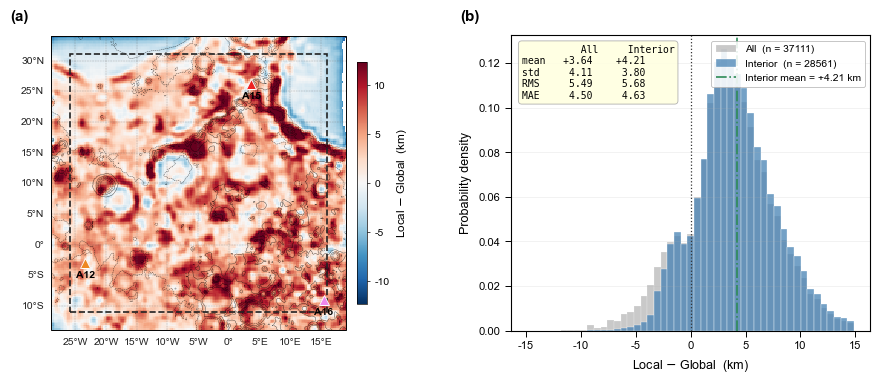

  → local_vs_global.png


In [ ]:
# ═══════════════════════════════════════════════════════════
# 图 X：局部 vs 全球月壳厚度差异（空间分布 + 直方图）
# ═══════════════════════════════════════════════════════════
print("局部 vs 全球月壳厚度对比…")

import xarray as xr
import pandas as pd
import matplotlib.patches as mpatches

# ── 1. 读取全球反演结果 ─────────────────────────────────
pkl_global = r"moho_inversion_result_1deg_35km.pkl"
with open(pkl_global, "rb") as f:
    obj = pickle.load(f, encoding="latin1")

global_moho_raw = obj["moho_grid"]            # km
lon_g_full      = obj["LON"]
lat_g_full      = obj["LAT"]

nlat_g, nlon_g = global_moho_raw.shape
lon_g = np.linspace(lon_g_full.min(), lon_g_full.max(), nlon_g)
lat_g = np.linspace(lat_g_full.min(), lat_g_full.max(), nlat_g)

global_moho_da = xr.DataArray(
    global_moho_raw,
    dims=("lat", "lon"),
    coords={"lat": lat_g, "lon": lon_g},
).sortby("lat")

# ── 1a. 经度 0–360 → -180–180 + 周期 padding ──────────
def to_pm180(da, lon_name="lon"):
    lon = da[lon_name].values
    if lon.max() > 180:
        new_lon = ((lon + 180) % 360) - 180
        da = da.assign_coords({lon_name: new_lon}).sortby(lon_name)
    first = da.isel({lon_name: 0}).assign_coords(
        {lon_name: float(da[lon_name][0]) + 360})
    last  = da.isel({lon_name: -1}).assign_coords(
        {lon_name: float(da[lon_name][-1]) - 360})
    da = xr.concat([last, da, first], dim=lon_name).sortby(lon_name)
    return da

global_moho_da = to_pm180(global_moho_da)

# ── 1b. 月壳厚度 = topo + Moho ─────────────────────────
data_file = "boueguer_frenquency_11km_d35km_1deg.csv"
df = pd.read_csv(data_file)
lon_raw = np.sort(df["lon"].unique())
lat_raw = np.sort(df["lat"].unique())

topo_grid = (
    df.pivot(index="lat", columns="lon", values="topo")
      .loc[lat_raw, lon_raw]
      .values
)
topo_da = xr.DataArray(
    topo_grid * 1e-3,
    dims=("lat", "lon"),
    coords={"lat": lat_raw, "lon": lon_raw},
).sortby("lat")
topo_da = to_pm180(topo_da)

topo_on_global  = topo_da.interp_like(global_moho_da)
global_crust_da = topo_on_global + global_moho_da
global_crust_da = global_crust_da.where(global_crust_da >= 0)

# ── 2. 插值到局部网格 ────────────────────────────────────
lat_local_1d = LAT_p[:, 0]
lon_local_1d = LON_p[0, :]

global_on_local = global_crust_da.interp(
    lat=("lat_new", lat_local_1d),
    lon=("lon_new", lon_local_1d),
    method="linear",
).values

local_crust_km  = ct_p
global_crust_km = global_on_local

# ── 3. 差异 + 内部掩膜 + 统计 ───────────────────────────
diff_km = local_crust_km - global_crust_km
finite  = np.isfinite(diff_km)

EDGE_DEG = 3
inner_mask = (
    (LON_p >= EXTENT[0] + EDGE_DEG) & (LON_p <= EXTENT[1] - EDGE_DEG) &
    (LAT_p >= EXTENT[2] + EDGE_DEG) & (LAT_p <= EXTENT[3] - EDGE_DEG)
)

diff_all   = diff_km[finite].ravel()
diff_inner = diff_km[finite & inner_mask].ravel()

def _stats(arr):
    return (
        float(np.mean(arr)),
        float(np.std(arr)),
        float(np.sqrt(np.mean(arr ** 2))),
        float(np.mean(np.abs(arr))),
        float(np.max(np.abs(arr))),
    )

mean_a, std_a, rms_a, mae_a, max_a = _stats(diff_all)
mean_i, std_i, rms_i, mae_i, max_i = _stats(diff_inner)

print("All :", f"mean={mean_a:+.2f}  std={std_a:.2f}  RMS={rms_a:.2f}")
print("Inner:", f"mean={mean_i:+.2f}  std={std_i:.2f}  RMS={rms_i:.2f}")

# ── 4. 画图：1×2 ────────────────────────────────────────
fig5 = plt.figure(figsize=(9.0, 3.6))
ax_a = fig5.add_subplot(1, 2, 1, projection=PROJ)  # 差值空间
ax_b = fig5.add_subplot(1, 2, 2)                   # 直方图

# ── (a) 差值空间分布 ────────────────────────────────────
vlim = float(np.nanpercentile(np.abs(diff_all), 98))
ax_a.set_extent(EXTENT, crs=PROJ)
im_a = ax_a.pcolormesh(LON_p, LAT_p, diff_km,
                       cmap="RdBu_r", vmin=-vlim, vmax=+vlim,
                       shading="auto", transform=PROJ, rasterized=True)
_topo_cont(ax_a, step=1000)
_gridlines(ax_a, EXTENT, left=True, bottom=True)
_mark_a15(ax_a)
_cbar(fig5, ax_a, im_a, "Local $-$ Global  (km)")


# ── (b) 差值直方图：all vs interior ────────────────────
_despine(ax_b)
bins = np.linspace(-vlim * 1.2, vlim * 1.2, 50)
ax_b.hist(diff_all,   bins=bins, density=True, alpha=0.45,
          color="#888888", edgecolor="white", linewidth=0.3,
          label=f"All  (n = {diff_all.size})")
ax_b.hist(diff_inner, bins=bins, density=True, alpha=0.75,
          color="steelblue", edgecolor="white", linewidth=0.3,
          label=f"Interior  (n = {diff_inner.size})")

ax_b.axvline(0, color="#333333", lw=0.9, ls=":")
ax_b.axvline(mean_i, color="seagreen", lw=1.2, ls="-.",
             label=f"Interior mean = {mean_i:+.2f} km")

ax_b.set_xlabel("Local $-$ Global  (km)", labelpad=5)
ax_b.set_ylabel("Probability density", labelpad=5)
ax_b.legend(fontsize=7.5, loc="upper right", framealpha=0.88)
ax_b.grid(axis="y", alpha=0.28, lw=0.4)
for sp in ax_b.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.8)

stats_txt = (f"          All     Interior\n"
             f"mean   {mean_a:+5.2f}    {mean_i:+5.2f}\n"
             f"std    {std_a:5.2f}    {std_i:5.2f}\n"
             f"RMS    {rms_a:5.2f}    {rms_i:5.2f}\n"
             f"MAE    {mae_a:5.2f}    {mae_i:5.2f}")
ax_b.text(0.03, 0.97, stats_txt, transform=ax_b.transAxes,
          fontsize=7.0, va="top", ha="left", family="monospace",
          bbox=dict(boxstyle="round,pad=0.35", facecolor="lightyellow",
                    edgecolor="0.65", alpha=0.88))

ax_b.text(-0.14, 1.04, "(b)", transform=ax_b.transAxes,
          fontsize=11, fontweight="bold", va="bottom", ha="left")
ax_a.text(-0.14, 1.04, "(a)", transform=ax_a.transAxes,
          fontsize=11, fontweight="bold", va="bottom", ha="left")

inner_rect = mpatches.Rectangle(
    (EXTENT[0] + EDGE_DEG, EXTENT[2] + EDGE_DEG),   # 左下角 (lon, lat)
    (EXTENT[1] - EXTENT[0]) - 2 * EDGE_DEG,         # 宽
    (EXTENT[3] - EXTENT[2]) - 2 * EDGE_DEG,         # 高
    linewidth=1.2, edgecolor="#222222", facecolor="none",
    linestyle="--", transform=PROJ, zorder=8,
    label="Interior",
)
ax_a.add_patch(inner_rect)

import matplotlib.patheffects

# ── 地质体标注 ───────────────────────────────────────────
# GEO_LABELS = [
#     # (lon, lat, text, ha, va, fontsize, color)
#     (-2.0, 32.0,  "Mare\nImbrium",      "center", "center", 8.5, "#1a1a1a"),
#     ( 5.5, 28.5,  "Montes\nApenninus",  "center", "center", 8.0, "#1a1a1a"),
#     (12.5, 28.0,  "Mare\nSerenitatis",  "center", "center", 8.5, "#1a1a1a"),
#     ( 4.0, 29.7,  "Archimedes",         "center", "center", 6.8, "#333333"),
#     ( 1.5, 30.3,  "Autolycus",          "center", "center", 6.8, "#333333"),
#     ( 0.0, 26.5,  "Palus\nPutredinis",  "center", "center", 6.8, "#333333"),
# ]

# for lon, lat, text, ha, va, fs, color in GEO_LABELS:
#     ax_a.text(lon, lat, text,
#               ha=ha, va=va, fontsize=fs, color=color,
#               fontstyle="italic", fontweight="semibold",
#               transform=PROJ, zorder=9,
#               path_effects=[
#                   matplotlib.patheffects.withStroke(
#                       linewidth=2.2, foreground="white", alpha=0.85)
#               ])

fig5.subplots_adjust(wspace=0.28, left=0.05, right=0.96,
                     top=0.95, bottom=0.13)
# fig5.savefig("figure/local_vs_global.png",
#             bbox_inches="tight", facecolor="white")
plt.show()
print("  → local_vs_global.png")